# Data Loading

In [1]:
import pandas as pd

df_anon = pd.read_csv("../data/data_anon.csv")

In [2]:
df_anon.describe()

,t,tempo_tot,temperatura,energia,fase_1,fase_2,fase_3,fase_4,fase_5,plastificante,antioxidante
count,1198.000000,1.198000e+03,1.198000e+03,1.198000e+03,1.198000e+03,1.198000e+03,1.198000e+03,1.198000e+03,1.198000e+03,1.198000e+03,1.198000e+03
mean,598.500000,-5.931075e-18,-3.143470e-16,-6.761425e-16,-4.744860e-17,-2.461396e-16,1.497596e-16,1.186215e-16,-2.965537e-18,-5.456589e-16,-5.456589e-16
std,345.977119,1.000000e+00,9.999998e-01,9.999998e-01,1.000000e+00,9.999999e-01,1.000000e+00,1.000000e+00,9.999982e-01,9.999996e-01,9.999893e-01
min,0.000000,-5.117283e+00,-1.570127e+01,-3.173882e+00,-1.357996e+00,-6.744601e+00,-4.038836e+00,-1.775205e+00,-2.889155e-02,-4.498655e+00,-1.381296e+00
25%,299.250000,-4.541766e-01,-4.250934e-01,-2.317182e-01,-5.169999e-01,1.898054e-02,2.383661e-01,-8.422709e-01,-2.889155e-02,-7.422182e-01,-7.902103e-01
50%,598.500000,2.997388e-01,3.926458e-03,2.341368e-01,-2.506844e-01,4.360378e-01,2.383661e-01,6.918870e-01,-2.889155e-02,1.631060e-01,-2.528597e-01
75%,897.750000,5.370826e-01,3.563357e-01,4.907351e-01,1.557973e-01,5.085695e-01,2.977717e-01,6.918870e-01,-2.889155e-02,8.884946e-01,4.027079e-01
max,1197.000000,3.245593e+00,4.202193e+00,2.898752e+00,9.799224e+00,5.948447e+00,8.733365e+00,2.143117e+00,3.458318e+01,1.145599e+00,3.723534e+00


# Exploratory Data Analysis (EDA)

## Timeline

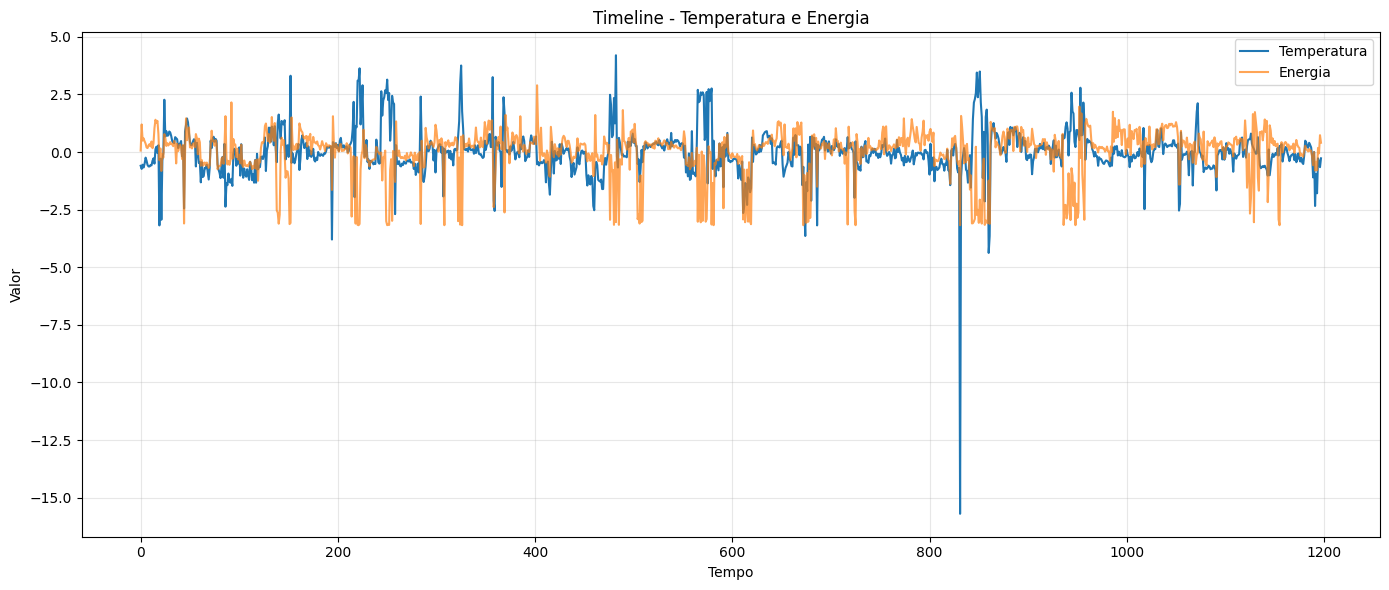

In [3]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14,6))

plt.plot(df_anon['t'], df_anon['temperatura'], label='Temperatura')
plt.plot(df_anon['t'], df_anon['energia'], label='Energia', alpha=0.7)

plt.title('Timeline - Temperatura e Energia')
plt.xlabel('Tempo')
plt.ylabel('Valor')
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## BoxPlot

### Variáveis principais

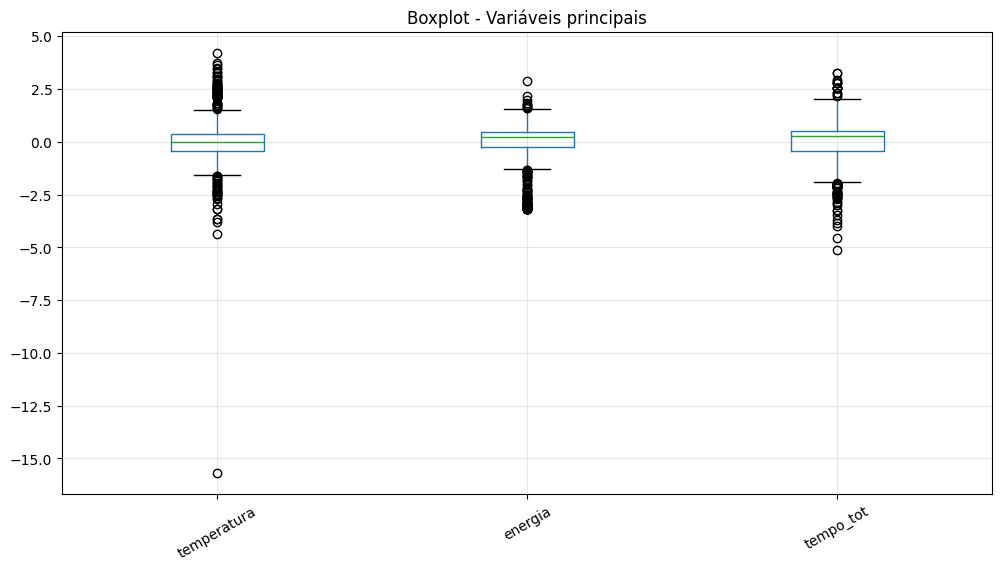

In [4]:
plt.figure(figsize=(12,6))

cols = ['temperatura', 'energia', 'tempo_tot']

df_anon[cols].boxplot()

plt.title('Boxplot - Variáveis principais')
plt.xticks(rotation=30)
plt.grid(alpha=0.3)

plt.show()

### Fases do Processo

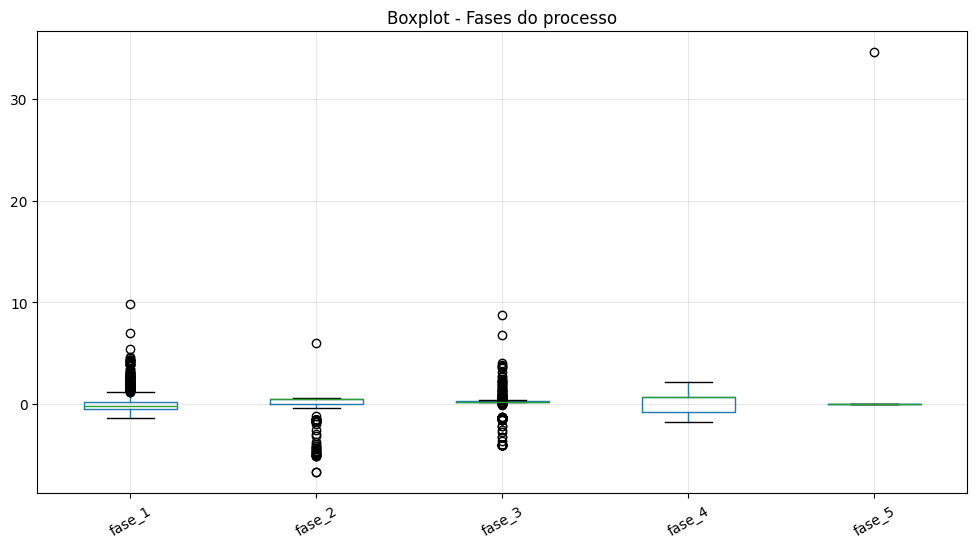

In [5]:
fase_cols = [c for c in df_anon.columns if 'fase' in c]

plt.figure(figsize=(12,6))

df_anon[fase_cols].boxplot()

plt.title('Boxplot - Fases do processo')
plt.xticks(rotation=30)
plt.grid(alpha=0.3)

plt.show()

## Scatter

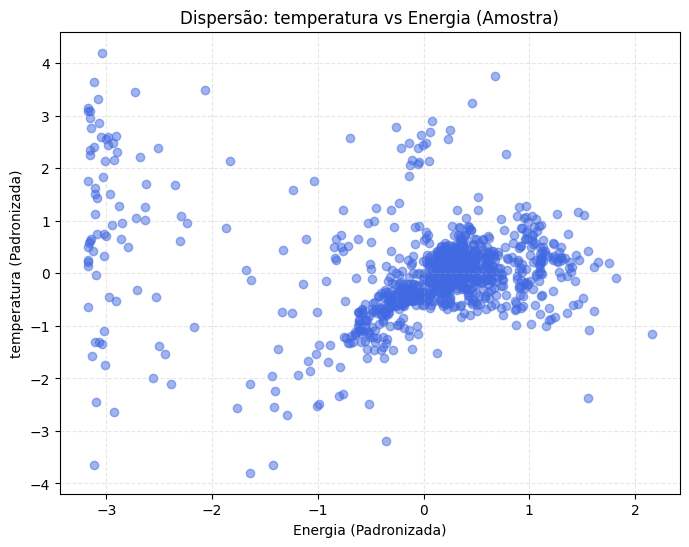

In [6]:
sample_df = df_anon.sample(min(1000, len(df_anon)), random_state=42)

plt.figure(figsize=(8, 6))

plt.scatter(sample_df['energia'], sample_df['temperatura'], alpha=0.5, color='royalblue')

plt.title('Dispersão: temperatura vs Energia (Amostra)')
plt.xlabel('Energia (Padronizada)')
plt.ylabel('temperatura (Padronizada)')
plt.grid(True, alpha=0.3, linestyle='--')

plt.show()

# Outlier Treatment

## Operação

In [7]:
import numpy as np

# limite (ajustável)
z_thresh = 5  # pode testar 3, 4 ou 5

# apenas colunas numéricas (sem 't')
cols = df_anon.columns.drop('t')

# máscara: mantém linhas dentro do limite em TODAS as colunas
mask = (df_anon[cols].abs() < z_thresh).all(axis=1)

# aplicar filtro
df_anon_clean = df_anon[mask].reset_index(drop=True)

# atualizar tempo
df_anon_clean['t'] = np.arange(len(df_anon_clean))

# =========================
# DIAGNÓSTICO
# =========================

print(f"Antes: {len(df_anon)} linhas")
print(f"Depois: {len(df_anon_clean)} linhas")
print(f"Removidos: {len(df_anon) - len(df_anon_clean)}")

display(df_anon_clean.describe())

Antes: 1198 linhas
Depois: 1181 linhas
Removidos: 17


,t,tempo_tot,temperatura,energia,fase_1,fase_2,fase_3,fase_4,fase_5,plastificante,antioxidante
count,1181.000000,1181.000000,1181.000000,1181.000000,1181.000000,1181.000000,1181.000000,1181.000000,1181.000000,1181.000000,1181.000000
mean,590.000000,0.014068,0.009453,0.018538,-0.019855,0.040829,0.026724,0.019199,-0.028892,0.006068,-0.004914
std,341.069641,0.947073,0.880948,0.982494,0.923844,0.855178,0.865320,0.989628,0.000000,0.999914,1.002160
min,0.000000,-3.986410,-4.378205,-3.173882,-1.301930,-4.931308,-4.038836,-1.775205,-0.028892,-4.498655,-1.381296
25%,295.000000,-0.426254,-0.425093,-0.215873,-0.517000,0.073379,0.238366,-0.821539,-0.028892,-0.742218,-0.800957
50%,590.000000,0.299739,0.003926,0.240301,-0.264701,0.436038,0.238366,0.691887,-0.028892,0.163106,-0.263607
75%,885.000000,0.537083,0.341014,0.493047,0.155797,0.508570,0.297772,0.691887,-0.028892,0.888495,0.370467
max,1180.000000,2.952404,4.202193,2.898752,4.641112,0.581101,4.010621,2.143117,-0.028892,1.145599,3.723534


## Verificação

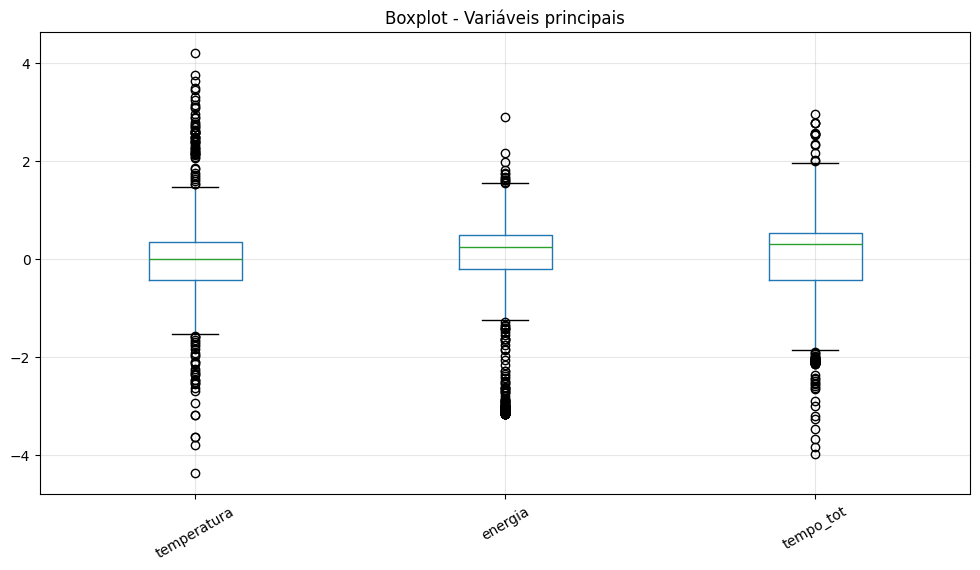

In [8]:
plt.figure(figsize=(12,6))

cols = ['temperatura', 'energia', 'tempo_tot']

df_anon_clean[cols].boxplot()

plt.title('Boxplot - Variáveis principais')
plt.xticks(rotation=30)
plt.grid(alpha=0.3)

plt.show()

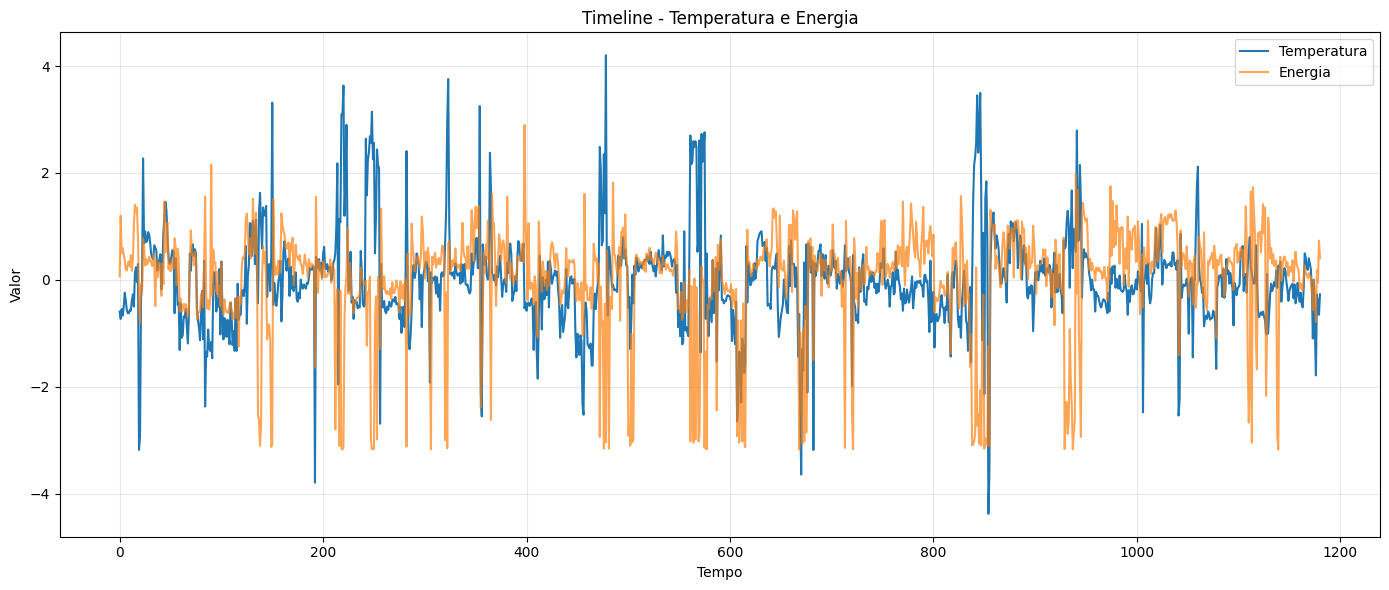

In [9]:
plt.figure(figsize=(14,6))

plt.plot(df_anon_clean['t'], df_anon_clean['temperatura'], label='Temperatura')
plt.plot(df_anon_clean['t'], df_anon_clean['energia'], label='Energia', alpha=0.7)

plt.title('Timeline - Temperatura e Energia')
plt.xlabel('Tempo')
plt.ylabel('Valor')
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Feature Engineering

In [10]:
df_feat = df_anon_clean.copy()

# derivadas simples
df_feat['temp_diff'] = df_feat['temperatura'].diff().fillna(0)
df_feat['energia_diff'] = df_feat['energia'].diff().fillna(0)

# razões de processo
df_feat['plast_por_tempo'] = df_feat['plastificante'] / (df_feat['tempo_tot'] + 1e-6)
df_feat['energia_por_tempo'] = df_feat['energia'] / (df_feat['tempo_tot'] + 1e-6)

In [11]:
df_feat.describe()

,t,tempo_tot,temperatura,energia,fase_1,fase_2,fase_3,fase_4,fase_5,plastificante,antioxidante,temp_diff,energia_diff,plast_por_tempo,energia_por_tempo
count,1181.000000,1181.000000,1181.000000,1181.000000,1181.000000,1181.000000,1181.000000,1181.000000,1181.000000,1181.000000,1181.000000,1181.000000,1181.000000,1181.000000,1181.000000
mean,590.000000,0.014068,0.009453,0.018538,-0.019855,0.040829,0.026724,0.019199,-0.028892,0.006068,-0.004914,0.000272,0.000288,-0.465606,1.091027
std,341.069641,0.947073,0.880948,0.982494,0.923844,0.855178,0.865320,0.989628,0.000000,0.999914,1.002160,0.834564,0.982586,15.462653,5.564241
min,0.000000,-3.986410,-4.378205,-3.173882,-1.301930,-4.931308,-4.038836,-1.775205,-0.028892,-4.498655,-1.381296,-5.362749,-4.695055,-242.893892,-77.068204
25%,295.000000,-0.426254,-0.425093,-0.215873,-0.517000,0.073379,0.238366,-0.821539,-0.028892,-0.742218,-0.800957,-0.214510,-0.281256,-1.826028,0.337403
50%,590.000000,0.299739,0.003926,0.240301,-0.264701,0.436038,0.238366,0.691887,-0.028892,0.163106,-0.263607,0.015322,-0.018301,-0.154481,0.701711
75%,885.000000,0.537083,0.341014,0.493047,0.155797,0.508570,0.297772,0.691887,-0.028892,0.888495,0.370467,0.229832,0.228858,1.155070,1.309502
max,1180.000000,2.952404,4.202193,2.898752,4.641112,0.581101,4.010621,2.143117,-0.028892,1.145599,3.723534,4.228910,4.780203,135.924942,78.679935


# Regime Detection (HMM)

## Normalização de Features

In [12]:
# Calculo Z Score
for c in ['plast_por_tempo', 'energia_por_tempo']:
    mean = df_feat[c].mean()
    std = df_feat[c].std() + 1e-6
    
    df_feat[c] = (df_feat[c] - mean) / std

# Clip em espaço normalizado
for c in ['plast_por_tempo', 'energia_por_tempo']:
    df_feat[c] = df_feat[c].clip(-4, 4)

# Aplicação em Diff's
for c in ['temp_diff', 'energia_diff']:
    mean = df_feat[c].mean()
    std = df_feat[c].std() + 1e-6
    
    df_feat[c] = (df_feat[c] - mean) / std
    df_feat[c] = df_feat[c].clip(-3, 3)

## Aplicação do Modelo

In [13]:
from hmmlearn.hmm import GaussianHMM

# =========================
# MATRIZ DE ENTRADA
# =========================

features = [
    'temperatura',
    'energia',
    'temp_diff',
    'energia_diff',
    'plast_por_tempo',
    'energia_por_tempo'
]

X = df_feat[features].values

# =========================
# HMM
# =========================

n_states = 4 #4

model = GaussianHMM(
    n_components=n_states,
    covariance_type='full',
    n_iter=200,
    random_state=42
)

model.fit(X)

# prever estados
states = model.predict(X)

df_feat['estado'] = states

c:\Users\victo\miniconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=5.
  warnings.warn(


## Visualização

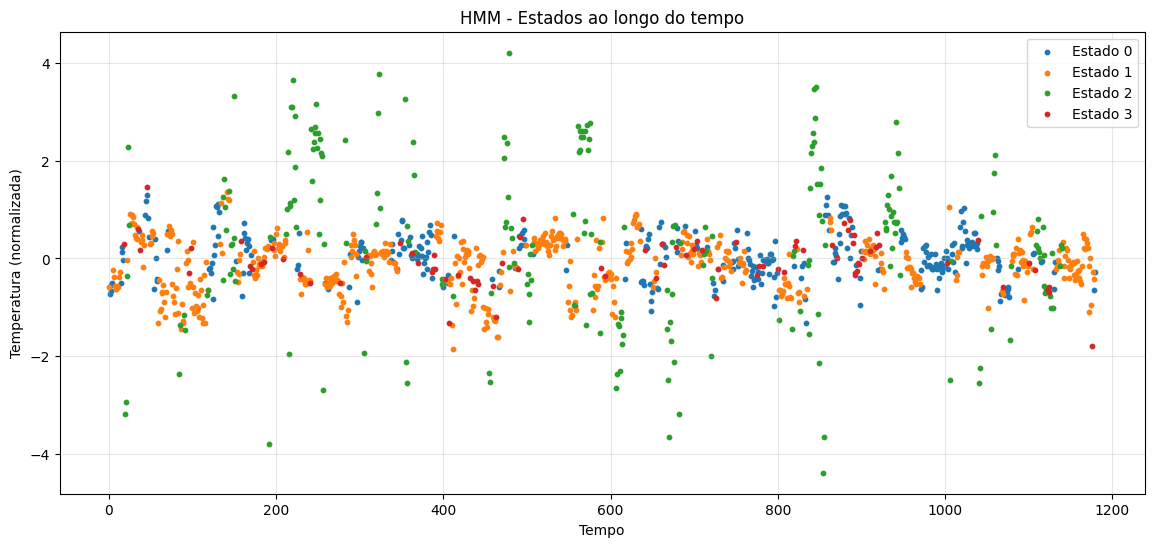

In [14]:
plt.figure(figsize=(14,6))

for s in range(n_states):
    mask = states == s
    plt.scatter(
        df_feat['t'][mask],
        df_feat['temperatura'][mask],
        label=f'Estado {s}',
        s=10
    )

plt.title('HMM - Estados ao longo do tempo')
plt.xlabel('Tempo')
plt.ylabel('Temperatura (normalizada)')
plt.legend()
plt.grid(alpha=0.3)

plt.show()

## Diagnóstico

In [15]:
print("Contagem por estado:")
print(pd.Series(states).value_counts().sort_index())

print("\nMédias por estado:")
display(df_feat.groupby('estado')[features].mean())

Contagem por estado:
0    326
1    545
2    224
3     86
Name: count, dtype: int64

Médias por estado:


,temperatura,energia,temp_diff,energia_diff,plast_por_tempo,energia_por_tempo
estado,,,,,,
0,0.036733,0.650777,0.014485,0.026994,-0.060575,0.038399
1,-0.135997,0.097681,-0.003190,-0.009209,0.028268,-0.086686
2,0.355994,-1.143441,0.048881,0.034180,0.024173,-0.007668
3,-0.074822,0.146920,-0.025944,-0.258466,0.094939,0.189336


# Degradation Modeling (BAFO)

## Aplicação

In [16]:
import sys
import os

sys.path.append(os.path.abspath(".."))
from src.bafo import bafo as run_bafo

# =========================
# BAFO POR ESTADO
# =========================

results_bafo = {}

states = df_feat['estado'].unique()

for s in states:
    
    df_state = df_feat[df_feat['estado'] == s].copy()
    
    if len(df_state) < 30:
        continue  # evitar estado com pouca amostra
    
    signal = df_state['temperatura'].values
    
    # baseline = parte mais "estável" do estado
    normal_signal = signal[:max(20, int(0.2 * len(signal)))]
    
    bafo_out = run_bafo(
        signal=signal,
        normal_signal=normal_signal,
        prior_fault=0.01,
        lambda_slope=1.6,
        tau=50,
        forgetting=0.995,
        threshold=0.75
    )
    
    results_bafo[s] = {
        'df_index': df_state.index,
        'posterior': bafo_out['posterior'],
        'deg_est': bafo_out['deg_est'],
        'detected_index': bafo_out['detected_index']
    }

print("Estados processados:", results_bafo.keys())

Estados processados: dict_keys([1, 0, 3, 2])


## Visualização

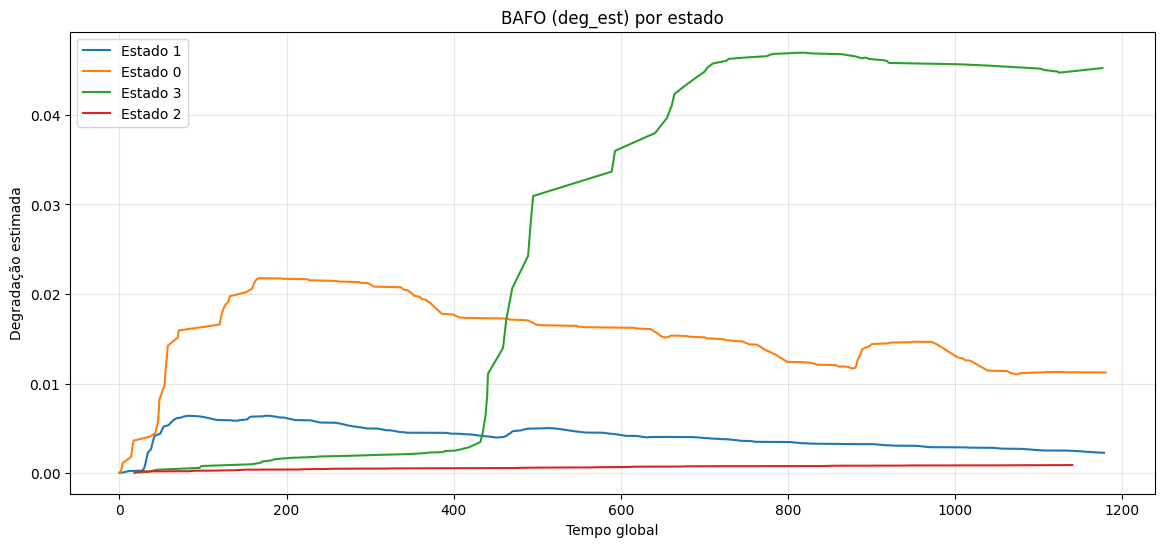

In [17]:
# =========================
# PLOT BAFO POR ESTADO
# =========================

import matplotlib.pyplot as plt

plt.figure(figsize=(14,6))

for s, res in results_bafo.items():
    idx = res['df_index']
    deg = res['deg_est']
    
    plt.plot(idx, deg, label=f'Estado {s}')

plt.title('BAFO (deg_est) por estado')
plt.xlabel('Tempo global')
plt.ylabel('Degradação estimada')
plt.legend()
plt.grid(alpha=0.3)

plt.show()

### Merging

In [18]:
df_feat['deg_est'] = 0.0

for s, res in results_bafo.items():
    df_feat.loc[res['df_index'], 'deg_est'] = res['deg_est']

# Risk Scoring

## Timeline

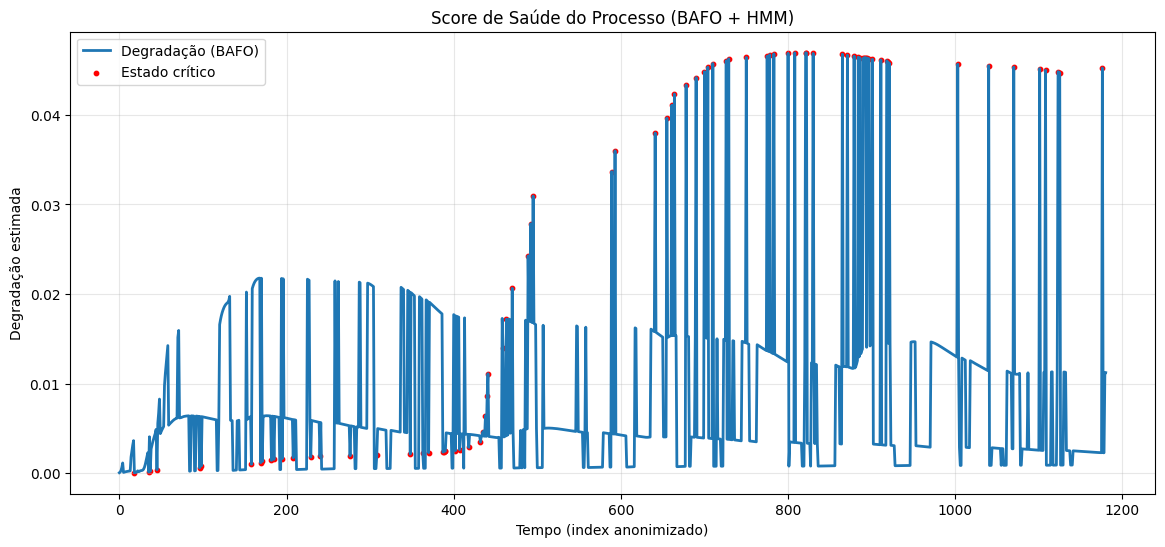

In [19]:
df_feat['risk'] = df_feat['deg_est'] * (df_feat['estado'] == 3)

plt.figure(figsize=(14,6))

plt.plot(df_feat.index, df_feat['deg_est'], label='Degradação (BAFO)', linewidth=2)

# destacar estado crítico (ex: estado 3)
mask_critico = df_feat['estado'] == 3

plt.scatter(
    df_feat.index[mask_critico],
    df_feat['deg_est'][mask_critico],
    color='red',
    s=10,
    label='Estado crítico'
)

plt.title('Score de Saúde do Processo (BAFO + HMM)')
plt.xlabel('Tempo (index anonimizado)')
plt.ylabel('Degradação estimada')
plt.legend()
plt.grid(alpha=0.3)

plt.show()

## Ranking

In [20]:
# =========================
# RANKING POR RISCO (BAFO)
# =========================

state_risk = df_feat.groupby('estado')['deg_est'].mean().sort_values()

print(state_risk)

# =========================
# ROTULAÇÃO SEMÂNTICA
# =========================

labels_ordered = [
    'Estável',
    'Leve Desvio',
    'Atenção',
    'Crítico'
]

state_labels = {}

for i, (state, _) in enumerate(state_risk.items()):
    state_labels[state] = labels_ordered[i]

print(state_labels)

estado
2    0.000638
1    0.004171
0    0.014684
3    0.027599
Name: deg_est, dtype: float64
{2: 'Estável', 1: 'Leve Desvio', 0: 'Atenção', 3: 'Crítico'}


## Visualização

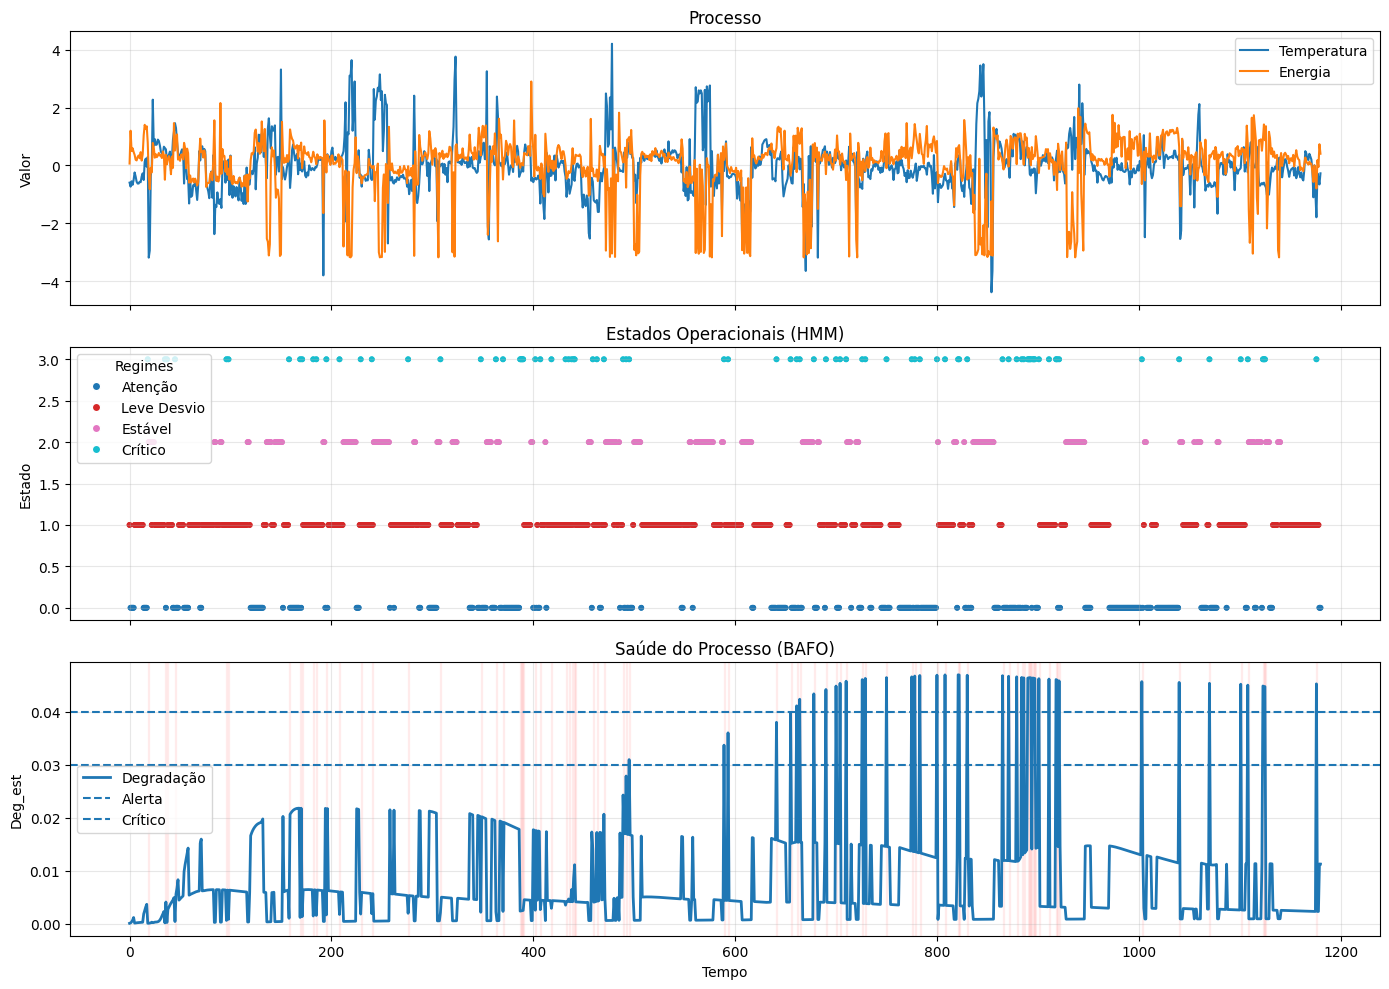

In [21]:
# =========================
# DASHBOARD OPERACIONAL
# =========================

fig, axes = plt.subplots(3, 1, figsize=(14,10), sharex=True)

# =========================
# 1. PROCESSO (SINAIS)
# =========================

axes[0].plot(df_feat.index, df_feat['temperatura'], label='Temperatura')
axes[0].plot(df_feat.index, df_feat['energia'], label='Energia')

axes[0].set_title('Processo')
axes[0].set_ylabel('Valor')
axes[0].legend()
axes[0].grid(alpha=0.3)


# =========================
# 2. ESTADOS (HMM)
# =========================

scatter = axes[1].scatter(
    df_feat.index,
    df_feat['estado'],
    c=df_feat['estado'],
    cmap='tab10',
    s=10
)

axes[1].set_title('Estados Operacionais (HMM)')
axes[1].set_ylabel('Estado')
axes[1].grid(alpha=0.3)

# =========================
# ESTADOS COM LEGENDA INTELIGENTE
# =========================

scatter = axes[1].scatter(
    df_feat.index,
    df_feat['estado'],
    c=df_feat['estado'],
    cmap='tab10',
    s=10
)

axes[1].set_title('Estados Operacionais (HMM)')
axes[1].set_ylabel('Estado')
axes[1].grid(alpha=0.3)

# legenda semântica
states = sorted(df_feat['estado'].unique())
colors = [scatter.cmap(scatter.norm(s)) for s in states]

handles = [
    plt.Line2D([0], [0], marker='o', color='w',
               label=state_labels.get(s, f'Estado {s}'),
               markerfacecolor=colors[i], markersize=6)
    for i, s in enumerate(states)
]

axes[1].legend(handles=handles, title='Regimes')


# =========================
# 3. SAÚDE (BAFO)
# =========================

for i in range(len(df_feat)):
    if df_feat['estado'].iloc[i] == 3:
        axes[2].axvspan(i, i+1, color='red', alpha=0.05)
        
axes[2].plot(df_feat.index, df_feat['deg_est'], label='Degradação', linewidth=2)

axes[2].axhline(0.03, linestyle='--', label='Alerta')
axes[2].axhline(0.04, linestyle='--', label='Crítico')

axes[2].set_title('Saúde do Processo (BAFO)')
axes[2].set_xlabel('Tempo')
axes[2].set_ylabel('Deg_est')
axes[2].legend()
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## Interpretation

In [22]:
print("Tempo em estado crítico:", (df_feat['estado']==3).mean())
print("Deg_est médio:", df_feat['deg_est'].mean())
print("Deg_est máximo:", df_feat['deg_est'].max())

Tempo em estado crítico: 0.07281964436917866
Deg_est médio: 0.008109087547503618
Deg_est máximo: 0.046940566570424336


## Síntese

A análise integrada entre regimes operacionais (HMM) e degradação dinâmica (BAFO) permitiu identificar que o processo apresenta episódios curtos de operação em estados críticos, responsáveis por aumentos significativos no indicador de degradação.

Embora esses eventos representem apenas cerca de 7% do tempo total, seu impacto é desproporcional, indicando que pequenas janelas de operação fora do regime ideal podem comprometer a qualidade do produto.

O comportamento observado sugere a existência de memória de degradação no sistema, onde efeitos acumulados não são completamente revertidos após o retorno ao regime normal.

Essa abordagem permite não apenas detectar desvios, mas também quantificar seu impacto ao longo do tempo, oferecendo uma ferramenta robusta para monitoramento e tomada de decisão em processos industriais.

## Overview

Este estudo explorou a aplicação combinada de técnicas de análise de dados e modelagem probabilística para monitoramento de um processo de mistura industrial (Banbury).

Inicialmente, foi realizada a limpeza e padronização dos dados, seguida de uma etapa de anonimização, garantindo independência temporal e adequação para uso analítico.

A análise exploratória evidenciou padrões operacionais distintos, especialmente na relação entre temperatura, energia e tempo de mistura.

Em seguida, foram construídas features derivadas com base em conhecimento de processo, destacando-se a razão entre plastificante e tempo de mistura, variável com impacto direto na qualidade do produto.

A aplicação de um modelo Hidden Markov Model (HMM) permitiu identificar diferentes regimes operacionais, segmentando o processo em estados com comportamentos distintos.

Posteriormente, foi aplicado o algoritmo BAFO (Bayesian Adaptive State Observer), responsável por estimar a degradação do processo ao longo do tempo.

A principal contribuição deste trabalho está na combinação das duas abordagens:

O HMM identifica em qual regime o processo está operando

O BAFO mede o nível de degradação dentro desse regime

Essa integração permitiu observar que determinados estados operacionais, especialmente aqueles associados a maior dinâmica do sistema, apresentam acúmulo progressivo de degradação, mesmo sem alterações evidentes nas variáveis principais.

Além disso, foi possível construir um indicador único de saúde do processo (deg_est), capaz de:

Detectar desvios de comportamento

Identificar regimes críticos

Antecipar potenciais problemas de qualidade

Os resultados sugerem que a metodologia pode ser utilizada como base para sistemas de monitoramento em tempo real, suporte à decisão operacional e detecção precoce de falhas em processos industriais.

“A combinação de modelos de regime e degradação permite não apenas identificar quando o processo muda, mas também avaliar se ele permanece saudável dentro dessas mudanças.”

# Monte Carlo Simulation

In [23]:
def simular_trajetoria(P, estado_inicial, deg_inicial, n_steps, impacto, beta):
    estados = [estado_inicial]
    deg = [deg_inicial]

    base = impacto[2]
    impacto_rel = {k: v - base for k, v in impacto.items()}

    for _ in range(n_steps):
        estado_atual = estados[-1]
        estado_next = np.random.choice(len(P), p=P[estado_atual])

        deg_next = (1 - beta) * deg[-1] + impacto_rel[estado_next]
        deg_next = max(0, deg_next)

        estados.append(estado_next)
        deg.append(deg_next)

    return np.array(estados), np.array(deg)

## Aplicação

In [24]:
import numpy as np
from src.simulation import simulate_trajectory
# =========================
# DADOS BASE
# =========================

# séries completas
states_full = df_feat['estado'].values
deg_full = df_feat['deg_est'].values

# =========================
# IMPACTO POR ESTADO (ABSOLUTO)
# =========================

impacto = {
    2: 0.000638,
    1: 0.004171,
    0: 0.014684,
    3: 0.027599
}

# =========================
# IMPACTO RELATIVO (baseline = estado estável)
# =========================

base = impacto[2]

impacto_rel = {
    k: v - base for k, v in impacto.items()
}

# =========================
# ESTIMAÇÃO DE BETA
# =========================

deg_t = deg_full[:-1]
deg_next = deg_full[1:]
delta_deg = deg_next - deg_t

# impacto histórico alinhado
impacto_seq = np.array([impacto_rel[s] for s in states_full[:-1]])

# regressão: Δdeg = impacto - beta * deg
y = delta_deg - impacto_seq
X = -deg_t

beta_est = np.sum(X * y) / np.sum(X**2)

# segurança
beta_est = np.clip(beta_est, 0.01, 0.3)

print(f"Beta estimado: {beta_est:.4f}")

# =========================
# SIMULAÇÃO MONTE CARLO
# =========================

P = model.transmat_

estado_inicial = states_full[-1]
deg_inicial = deg_full[-1]

n_sim = 3500
n_steps = 150

resultados = [
    simulate_trajectory(P, estado_inicial, deg_inicial, n_steps, impacto_rel, beta_est)
    for _ in range(n_sim)
]

Beta estimado: 0.3000


## Limite (Threshold)

In [25]:
# =========================
# MÉTRICAS DE RISCO
# =========================

q95 = np.percentile(deg_full, 95)
q98 = np.percentile(deg_full, 98)
q99 = np.percentile(deg_full, 99)
alerta = q95
atencao = q98
critico = q99
threshold = critico

# probabilidade de cruzar threshold
count = 0

for _, deg in resultados:
    if np.any(deg > threshold):
        count += 1

prob = count / len(resultados)

# tempo até risco
tempos = []

for _, deg in resultados:
    idx = np.where(deg > threshold)[0]
    
    if len(idx) > 0:
        tempos.append(idx[0])
    else:
        tempos.append(len(deg))  # censurado (não atingiu)

tempo_medio = np.mean(tempos)

print(f'Probabilidade de ultrapassar estado crítico: {100*prob:.2f}%')
print(f'Tempo médio até risco: {tempo_medio:.1f} ciclos')

Probabilidade de ultrapassar estado crítico: 99.74%
Tempo médio até risco: 24.2 ciclos


## Visualização

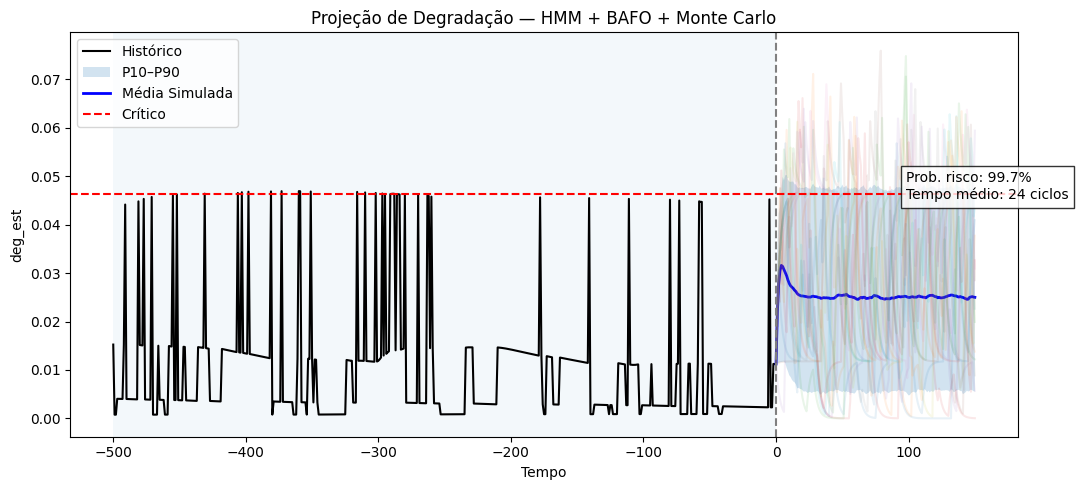

In [26]:
# =========================
# DADOS
# =========================

historico = df_feat['deg_est'].values[-500:]
n_hist = len(historico)

degs = np.array([deg for _, deg in resultados])
media = degs.mean(axis=0)
p90 = np.percentile(degs, 90, axis=0)
p10 = np.percentile(degs, 10, axis=0)

# =========================
# EIXOS
# =========================

t_hist = np.arange(-n_hist, 0)
t_fut = np.arange(0, len(media))

# =========================
# MÉTRICAS
# =========================

count = sum(np.any(deg > threshold) for _, deg in resultados)
prob = count / len(resultados)

tempos = []
for _, deg in resultados:
    idx = np.where(deg > threshold)[0]
    if len(idx) > 0:
        tempos.append(idx[0])
    else:
        tempos.append(len(deg))

tempo_medio = np.mean(tempos)

# =========================
# PLOT
# =========================

plt.figure(figsize=(11,5))

# HISTÓRICO
plt.plot(t_hist, historico, color='black', label='Histórico')

# ENVELOPE FUTURO
plt.fill_between(t_fut, p10, p90, alpha=0.20, label='P10–P90')

# MÉDIA
plt.plot(t_fut, media, color='blue', linewidth=2, label='Média Simulada')

# ALGUMAS TRAJETÓRIAS
for i in range(15):
    _, deg = resultados[i]
    plt.plot(t_fut, deg, alpha=0.1)

# THRESHOLD
plt.axhline(y=threshold, linestyle='--', color='red', label='Crítico')

# DIVISÃO
plt.axvline(x=0, linestyle='--', color='gray')

# SOMBRA PASSADO
plt.axvspan(-n_hist, 0, alpha=0.05)

# =========================
# ANOTAÇÃO (OURO)
# =========================

texto = (
    f"Prob. risco: {100*prob:.1f}%\n"
    f"Tempo médio: {tempo_medio:.0f} ciclos"
)

plt.text(
    0.65 * len(media),              # posição x
    max(p90)*0.9,                  # posição y
    texto,
    fontsize=10,
    bbox=dict(facecolor='white', alpha=0.8)
)

# =========================
# FINAL
# =========================

plt.title("Projeção de Degradação — HMM + BAFO + Monte Carlo")
plt.xlabel("Tempo")
plt.ylabel("deg_est")

plt.legend(loc='upper left')
plt.tight_layout()
plt.show()

# Results & Interpretation

## Métricas

### Cálculo

In [27]:
from src.metrics import exposure, exposure_weighted

deg_hist = df_feat['deg_est'].values

health_exposure = exposure(deg_hist, threshold)
health_weighted = exposure_weighted(deg_hist, threshold)

print("Exposição (tempo acima):", health_exposure)
print("Exposição ponderada:", health_weighted)

exp_simples = []
exp_pond = []

for _, deg in resultados:
    exp_simples.append(exposure(deg, threshold))
    exp_pond.append(exposure_weighted(deg, threshold))

print("Exposição média (tempo):", np.mean(exp_simples))
print("Exposição média ponderada:", np.mean(exp_pond))

risk_exposure = np.mean(exp_pond)

if risk_exposure < 0.05:
    status = "Saudável"
elif risk_exposure < 0.15:
    status = "Atenção"
else:
    status = "Crítico"

print(f"Status do processo: {status}")

Exposição (tempo acima): 12
Exposição ponderada: 0.004006128312066197
Exposição média (tempo): 19.218
Exposição média ponderada: 0.12648192575522627
Status do processo: Atenção


## 🧠 Conclusão — HMM + BAFO + Monte Carlo

A integração entre a modelagem de regimes operacionais (HMM) e a estimativa dinâmica de degradação (BAFO) permitiu evoluir a análise do processo de uma abordagem descritiva para um modelo preditivo probabilístico.

A partir da simulação de múltiplas trajetórias futuras via Monte Carlo, foi possível estimar o comportamento esperado da degradação sob diferentes cenários operacionais, incorporando:

- dinâmica de transição entre regimes  
- efeito acumulativo da degradação  
- incerteza inerente ao processo  

---

### 📊 Principais Resultados

🔴 Probabilidade relevante de atingir estado crítico sob determinadas trajetórias  
⏱️ Tempo médio até risco: ~24 ciclos  
♻️ Evidência de memória de degradação no sistema  
📈 Exposição futura ao risco significativamente superior ao histórico observado  

---

### 🔍 Interpretação

Os resultados indicam que:

- O processo atualmente opera em condição controlada, com baixa exposição histórica ao risco  
- Entretanto, as simulações mostram aumento relevante da exposição futura, indicando vulnerabilidade a determinadas sequências operacionais  
- Pequenos períodos fora do regime ideal têm impacto desproporcional devido ao efeito acumulativo de degradação  

---

### ⚙️ Implicações Operacionais

A metodologia permite:

📈 Antecipar riscos antes da falha  
🛠️ Priorizar intervenções com base em exposição acumulada ao risco  
🔄 Evoluir de monitoramento reativo para gestão preditiva  

---

### 🚀 Síntese

O modelo não apenas identifica mudanças de regime,  
mas quantifica o risco e a exposição acumulada associada a essas mudanças ao longo do tempo.

---

### 💡 Takeaway

Saímos de um sistema de detecção  
para um sistema de gestão contínua de risco operacional.